<a href="https://colab.research.google.com/github/munawarali93/Quant-Finance-Summer-2026/blob/main/Quant_finance_ERDOS_Summer2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import yfinance as yf

##Generating FBM

##Generates sample paths of fractional Brownian Motion using the Davies Harte method
##Arguments:
#T:      length of time (in years)
#N:      number of time steps within timeframe
#H:      Hurst parameter

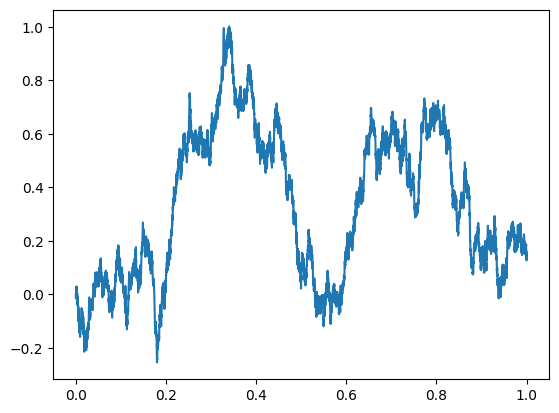

In [21]:
def davies_harte(N, T, H):
    gamma = lambda k,H: 0.5*(np.abs(k-1)**(2*H) - 2*np.abs(k)**(2*H) + np.abs(k+1)**(2*H))
    g = [gamma(k,H) for k in range(0,N)];    r = g + [0] + g[::-1][0:N-1]

    # Step 1 (eigenvalues)
    j = np.arange(0,2*N);   k = 2*N-1
    lk = np.fft.fft(r*np.exp(2*np.pi*complex(0,1)*k*j*(1/(2*N))))[::-1]

    # Step 2 (get random variables)
    Vj = np.zeros((2*N,2), dtype=complex);
    Vj[0,0] = np.random.standard_normal();  Vj[N,0] = np.random.standard_normal()

    for i in range(1,N):
        Vj1 = np.random.standard_normal();    Vj2 = np.random.standard_normal()
        Vj[i][0] = Vj1; Vj[i][1] = Vj2; Vj[2*N-i][0] = Vj1;    Vj[2*N-i][1] = Vj2

    # Step 3 (compute Z)
    wk = np.zeros(2*N, dtype=complex)
    wk[0] = np.sqrt((lk[0]/(2*N)))*Vj[0][0];
    wk[1:N] = np.sqrt(lk[1:N]/(4*N))*((Vj[1:N].T[0]) + (complex(0,1)*Vj[1:N].T[1]))
    wk[N] = np.sqrt((lk[0]/(2*N)))*Vj[N][0]
    wk[N+1:2*N] = np.sqrt(lk[N+1:2*N]/(4*N))*(np.flip(Vj[1:N].T[0]) - (complex(0,1)*np.flip(Vj[1:N].T[1])))

    Z = np.fft.fft(wk);     fGn = Z[0:N]
    fBm = np.cumsum(fGn)*(N**(-H))
    fBm = (T**H)*(fBm)
    path = np.array([0] + list(fBm))
    return path


#Check
times = np.linspace(0, 1, 10000)
B = davies_harte(N = 10000, T = 1, H = 0.5)
B = B[:-1].real.astype(float)
plt.plot(times, B)
plt.show()

##Roughness Estimator


1.   Making blocks
2.   W_statistics
  *   Computes the normalized p-variation statistic W(p).
  *   Input
        x : one-dimensional time series,
        p : power,
        K : number of coarse blocks,
        T : time horizon,
  *   Output: W(p)
3. estimate_H: The estimator solves approximately W(p_hat) = T, and returns H_hat = 1 / p_hat.





In [12]:
def _make_blocks(L, K):
    K = int(K)
    K = max(2, min(K, L))
    blocks = np.linspace(0, L, K + 1, dtype=int)
    blocks = np.unique(blocks)
    if len(blocks) < 3:
        raise ValueError("Too few non-empty blocks. Try smaller K.")
    return blocks


def W_statistic(x, p, K=None, T=1.0, eps=1e-14):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        raise ValueError("Need at least 3 observations.")

    L = len(x) - 1

    if K is None:
        K = int(np.floor(np.sqrt(L)))

    blocks = _make_blocks(L, K)

    t = np.linspace(0.0, T, len(x))
    dx = np.diff(x)
    abs_dx = np.abs(dx)

    W = 0.0

    for start, end in zip(blocks[:-1], blocks[1:]):
        numerator = np.abs(x[end] - x[start]) ** p
        denominator = np.sum(abs_dx[start:end] ** p)

        if denominator <= eps or not np.isfinite(denominator):
            continue

        block_length = t[end] - t[start]
        W += (numerator / denominator) * block_length

    return float(W)


def estimate_H(
    x,
    K=None,
    T=1.0,
    p_min=1.05,
    p_max=12.0,
    n_grid=1000,
    p_grid=None,
    return_details=False
):

    x = np.asarray(x, dtype=float).reshape(-1)
    x = x[np.isfinite(x)]

    if len(x) < 3:
        raise ValueError("Need at least 3 finite observations.")

    dx = np.diff(x)
    scale = np.nanstd(dx)

    if np.isfinite(scale) and scale > 0:
        x_work = (x - np.nanmean(x)) / scale
    else:
        x_work = x - np.nanmean(x)

    # Candidate p-values
    if p_grid is None:
        p_grid = np.linspace(p_min, p_max, n_grid)
    else:
        p_grid = np.asarray(p_grid, dtype=float)

    # Compute W(p) for all p
    W_values = np.array([
        W_statistic(x_work, p, K=K, T=T)
        for p in p_grid
    ])

    valid = np.isfinite(W_values)

    if valid.sum() < 3:
        if return_details:
            details = {
                "H_hat": np.nan,
                "p_hat": np.nan,
                "K": int(K) if K is not None else int(np.floor(np.sqrt(len(x) - 1))),
                "T": T,
                "p_grid": p_grid,
                "W_values": W_values,
                "method": "failed_not_enough_valid_values",
                "crossings": [],
                "min_abs_W_minus_T": np.nan,
            }
            return np.nan, details

        return np.nan

    p_valid = p_grid[valid]
    W_valid = W_values[valid]

    y = W_valid - T

    # First: find closest grid point
    closest_idx = int(np.argmin(np.abs(y)))
    p_closest = float(p_valid[closest_idx])

    # Second: improve by linear interpolation if a crossing exists
    crossings = []

    for i in range(len(p_valid) - 1):
        y0 = y[i]
        y1 = y[i + 1]

        if y0 == 0:
            crossings.append(float(p_valid[i]))

        elif y0 * y1 < 0:
            p0, p1 = p_valid[i], p_valid[i + 1]
            w0, w1 = W_valid[i], W_valid[i + 1]

            if w1 != w0:
                p_cross = p0 + (T - w0) * (p1 - p0) / (w1 - w0)
                crossings.append(float(p_cross))

    if len(crossings) > 0:
        p_hat = min(crossings, key=lambda p: abs(p - p_closest))
        method = "linear_interpolated_crossing"
    else:
        p_hat = p_closest
        method = "closest_grid_point_no_crossing"

    H_hat = 1.0 / p_hat

    if return_details:
        details = {
            "H_hat": float(H_hat),
            "p_hat": float(p_hat),
            "K": int(K) if K is not None else int(np.floor(np.sqrt(len(x) - 1))),
            "T": T,
            "p_grid": p_grid,
            "W_values": W_values,
            "p_valid": p_valid,
            "W_valid": W_valid,
            "method": method,
            "crossings": crossings,
            "min_abs_W_minus_T": float(np.min(np.abs(y))),
        }

        return float(H_hat), details

    return float(H_hat)

#Experiment 1: Verifiying the estimator on fractional Brownian motion
##Simulates many fBM paths for several true H values.
##For each H, it estimates H_hat over n_paths independent paths.

In [11]:
def monte_carlo_fbm_many_H(
    H_values=[0.1, 0.3, 0.5, 0.8],
    N=1000,
    T=1.0,
    n_paths=100,
    K=None,
    seed=123
):
    np.random.seed(seed)

    summaries = []

    for H_true in H_values:
        estimates = []

        for m in range(n_paths):
            B = davies_harte(N=N, T=T, H=H_true)
            B = B[:-1].real.astype(float)
            H_hat = estimate_H(B, K=K, T=T)
            estimates.append(H_hat)
        estimates = np.array(estimates, dtype=float)
        estimates = estimates[np.isfinite(estimates)]

        summary = {
            "H_true": H_true,
            "N": N,
            "T": T,
            "K": int(K) if K is not None else int(np.floor(np.sqrt(len(B) - 1))),
            "n_paths": len(estimates),
            "min": np.min(estimates),
            "mean": np.mean(estimates),
            "std": np.std(estimates, ddof=1),
            "max": np.max(estimates),
            "bias": np.mean(estimates) - H_true,
            "rmse": np.sqrt(np.mean((estimates - H_true) ** 2)),
            "estimates": estimates
        }

        summaries.append(summary)

    return summaries



#converting to latex table code
def summaries_to_latex_table(summaries, digits=4):
    rows = ""
    for s in summaries:
        rows += (
            f'{s["H_true"]:.1f} & '
            f'{s["min"]:.{digits}f} & '
            f'{s["mean"]:.{digits}f} & '
            f'{s["std"]:.{digits}f} & '
            f'{s["max"]:.{digits}f} \\\\\n'
        )

    N = summaries[0]["N"]
    K = summaries[0]["K"]
    n_paths = summaries[0]["n_paths"]

    latex = rf"""
\begin{{table}}[H]
\centering
\begin{{tabular}}{{ccccc}}
\hline
$H$ & Min. & Mean & Std. & Max. \\
\hline
{rows}\hline
\end{{tabular}}
\caption{{Summary statistics for the estimated roughness index $\widehat{{H}}_{{L,K}}$ for fractional Brownian motion. The simulations use $N={N}$, $K={K}$, and {n_paths} independent paths for each value of $H$.}}
\end{{table}}
"""
    return latex

H_values = [0.1, 0.3, 0.5, 0.8]

N = 10000
T = 1.0
n_paths = 50

K = int(np.floor(np.sqrt(N - 1)))

summaries = monte_carlo_fbm_many_H(
    H_values=H_values,
    N=N,
    T=T,
    n_paths=n_paths,
    K=K,
    seed=123
)

for s in summaries:
    print(
        f'H={s["H_true"]:.1f}, '
        f'Min={s["min"]:.4f}, '
        f'Mean={s["mean"]:.4f}, '
        f'Std={s["std"]:.4f}, '
        f'Max={s["max"]:.4f}'
    )

print("\nLaTeX code:")
print(summaries_to_latex_table(summaries, digits=4))

H=0.1, Min=0.0833, Mean=0.1060, Std=0.0201, Max=0.1624
H=0.3, Min=0.2460, Mean=0.2991, Std=0.0197, Max=0.3460
H=0.5, Min=0.4693, Mean=0.5036, Std=0.0117, Max=0.5273
H=0.8, Min=0.7379, Mean=0.7848, Std=0.0206, Max=0.8447

LaTeX code:

\begin{table}[H]
\centering
\begin{tabular}{ccccc}
\hline
$H$ & Min. & Mean & Std. & Max. \\
\hline
0.1 & 0.0833 & 0.1060 & 0.0201 & 0.1624 \\
0.3 & 0.2460 & 0.2991 & 0.0197 & 0.3460 \\
0.5 & 0.4693 & 0.5036 & 0.0117 & 0.5273 \\
0.8 & 0.7379 & 0.7848 & 0.0206 & 0.8447 \\
\hline
\end{tabular}
\caption{Summary statistics for the estimated roughness index $\widehat{H}_{L,K}$ for fractional Brownian motion. The simulations use $N=10000$, $K=99$, and 50 independent paths for each value of $H$.}
\end{table}



##Graphical representation

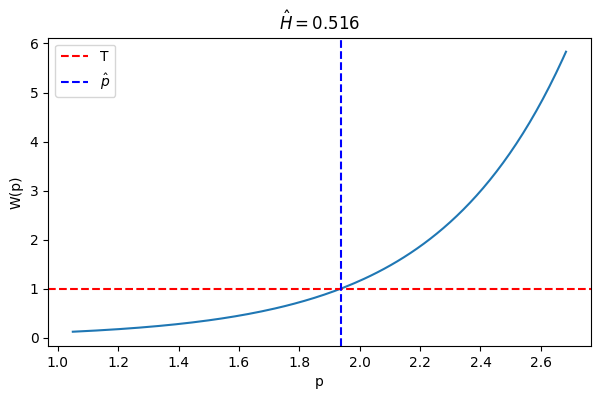

In [26]:
H_hat, details = estimate_H(B, return_details=True)
p_grid = details["p_grid"]
W_values = details["W_values"]

plt.figure(figsize=(7, 4))
plt.plot(p_grid[:150], W_values[:150])
plt.axhline(details["T"], linestyle="--", color = "red", label="T")
plt.axvline(details["p_hat"], linestyle="--",color = "blue", label=r"$\hat p$")
plt.xlabel("p")
plt.ylabel("W(p)")
plt.title(rf"$\hat H = {H_hat:.3f}$")
plt.legend()
plt.savefig("roughness_estimator.png")
plt.show()

#Experiment 2: Fractional OU stochastic-volatility model
##Simulates the model
*   dS_t = sigma_t S_t dB_t,
*   sigma_t = sigma0 exp(Y_t), dY_t = -gamma Y_t dt + theta dB_t^H.
##Here B_t is standard Brownian motion and B_t^H is fractional Brownian motion.

##For one true H:

    1. Simulate fractional OU stochastic volatility.
    2. Compute realized volatility from the stock-price path.
    3. Estimate H from instantaneous volatility sigma_t.
    4. Estimate H from realized volatility RV_t.

In [31]:
def simulate_fractional_ou_sv(
    H,
    N=10000,
    T=1.0,
    gamma=1.0,
    theta=1.0,
    sigma0=1.0,
    S0=1.0,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    BH = davies_harte(N=N, T=T, H=H)
    BH = BH[:-1].real.astype(float)

    n_steps = len(BH) - 1

    if n_steps < 10:
        raise ValueError("The generated fBM path is too short.")

    dt = T / n_steps

    # Fractional Brownian increments
    dBH = np.diff(BH)

    # Standard Brownian increments for the stock price
    dB = np.sqrt(dt) * np.random.randn(n_steps)

    # Arrays
    Y = np.zeros(n_steps + 1)
    sigma = np.zeros(n_steps + 1)
    logS = np.zeros(n_steps + 1)

    Y[0] = 0.0
    sigma[0] = sigma0
    logS[0] = np.log(S0)

    # Euler-Maruyama scheme:
    for i in range(n_steps):
        sigma[i] = sigma0 * np.exp(Y[i])

        Y[i + 1] = Y[i] - gamma * Y[i] * dt + theta * dBH[i]

        logS[i + 1] = (
            logS[i]
            - 0.5 * sigma[i] ** 2 * dt
            + sigma[i] * dB[i]
        )

    sigma[-1] = sigma0 * np.exp(Y[-1])
    S = np.exp(logS)

    return {
        "time": np.linspace(0.0, T, n_steps + 1),
        "Y": Y,
        "sigma": sigma,
        "logS": logS,
        "S": S,
        "dt": dt,
        "H_true": H
    }

def compute_realized_volatility(
    logS,
    window_size=300,
    step=1,
    normalize_by_window=False,
    dt=None
):

    logS = np.asarray(logS, dtype=float).reshape(-1)
    returns = np.diff(logS)

    m = int(window_size)

    if m < 2:
        raise ValueError("window_size must be at least 2.")

    if m > len(returns):
        raise ValueError("window_size is larger than the number of returns.")

    rv_values = []
    rv_indices = []

    # end is the endpoint of the rolling window in the returns array
    for end in range(m, len(returns) + 1, step):
        window_returns = returns[end - m:end]

        rv = np.sqrt(np.sum(window_returns ** 2))

        if normalize_by_window:
            if dt is None:
                raise ValueError("dt must be provided if normalize_by_window=True.")
            rv = rv / np.sqrt(m * dt)

        rv_values.append(rv)

        # This index aligns RV with logS[end]
        rv_indices.append(end)

    return np.array(rv_values), np.array(rv_indices)


def estimate_sigma_and_rv_H(
    H_true,
    N=10000,
    T=1.0,
    gamma=1.0,
    theta=1.0,
    sigma0=1.0,
    S0=1.0,
    rv_window=300,
    rv_step=1,
    K_est=None,
    seed=None
):

    sim = simulate_fractional_ou_sv(
        H=H_true,
        N=N,
        T=T,
        gamma=gamma,
        theta=theta,
        sigma0=sigma0,
        S0=S0,
        seed=seed
    )

    sigma = sim["sigma"]
    logS = sim["logS"]
    dt = sim["dt"]

    rv, rv_indices = compute_realized_volatility(
        logS=logS,
        window_size=rv_window,
        step=rv_step,
        normalize_by_window=False,
        dt=dt
    )

    # Align instantaneous volatility with the realized-volatility times
    sigma_aligned = sigma[rv_indices]

    # For roughness estimation, we can use T=1 for both paths
    H_sigma_hat = estimate_H(sigma_aligned, K=K_est, T=1.0)
    H_rv_hat = estimate_H(rv, K=K_est, T=1.0)

    return {
        "H_true": H_true,
        "H_sigma_hat": H_sigma_hat,
        "H_rv_hat": H_rv_hat,
        "sigma": sigma,
        "sigma_aligned": sigma_aligned,
        "rv": rv,
        "S": sim["S"],
        "logS": logS,
        "time": sim["time"]
    }

def run_fractional_ou_table(
    H_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    N=10000,
    T=1.0,
    gamma=1.0,
    theta=1.0,
    sigma0=1.0,
    S0=1.0,
    rv_window=300,
    rv_step=1,
    K_est=None,
    seed=123
):
    rows = []

    for k, H_true in enumerate(H_values):

        result = estimate_sigma_and_rv_H(
            H_true=H_true,
            N=N,
            T=T,
            gamma=gamma,
            theta=theta,
            sigma0=sigma0,
            S0=S0,
            rv_window=rv_window,
            rv_step=rv_step,
            K_est=K_est,
            seed=seed + k
        )

        rows.append({
            "H_true": H_true,
            "H_sigma_hat": result["H_sigma_hat"],
            "H_rv_hat": result["H_rv_hat"]
        })

    return rows

def fractional_ou_table_to_latex(rows, digits=3):
    """
    Creates a LaTeX table like the paper:

        H | Instantaneous volatility | Realized volatility
    """

    body = ""

    for row in rows:
        body += (
            f'{row["H_true"]:.2f} & '
            f'{row["H_sigma_hat"]:.{digits}f} & '
            f'{row["H_rv_hat"]:.{digits}f} \\\\\n'
        )

    latex = rf"""
\begin{{table}}[H]
\centering
\begin{{tabular}}{{ccc}}
\hline
$H$ & Instantaneous volatility & Realized volatility \\
\hline
{body}\hline
\end{{tabular}}
\caption{{Estimated roughness index $\widehat{{H}}_{{L,K}}$ for instantaneous volatility and realized volatility in the fractional Ornstein--Uhlenbeck stochastic-volatility model.}}
\end{{table}}
"""
    return latex





#Run the experiment
H_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
N = 90000
T = 1.0
rv_window = 10
rv_step = 1
K_est = 300
rows = run_fractional_ou_table(
    H_values=H_values,
    N=N,
    T=T,
    gamma=1.0,
    theta=1.0,
    sigma0=1.0,
    S0=1.0,
    rv_window=rv_window,
    rv_step=rv_step,
    K_est=K_est,
    seed=123
)
print("Numerical table:")
for row in rows:
    print(
        f'H={row["H_true"]:.2f}, '
        f'H_hat(sigma)={row["H_sigma_hat"]:.4f}, '
        f'H_hat(RV)={row["H_rv_hat"]:.4f}'
    )
print("\nLaTeX table:")
print(fractional_ou_table_to_latex(rows, digits=3))

Numerical table:
H=0.10, H_hat(sigma)=0.0875, H_hat(RV)=0.2236
H=0.20, H_hat(sigma)=0.2106, H_hat(RV)=0.2183
H=0.30, H_hat(sigma)=0.2935, H_hat(RV)=0.2007
H=0.40, H_hat(sigma)=0.3920, H_hat(RV)=0.1447
H=0.50, H_hat(sigma)=0.4986, H_hat(RV)=0.1664
H=0.60, H_hat(sigma)=0.5967, H_hat(RV)=0.1639
H=0.70, H_hat(sigma)=0.6834, H_hat(RV)=0.1627
H=0.80, H_hat(sigma)=0.7727, H_hat(RV)=0.1579

LaTeX table:

\begin{table}[H]
\centering
\begin{tabular}{ccc}
\hline
$H$ & Instantaneous volatility & Realized volatility \\
\hline
0.10 & 0.088 & 0.224 \\
0.20 & 0.211 & 0.218 \\
0.30 & 0.293 & 0.201 \\
0.40 & 0.392 & 0.145 \\
0.50 & 0.499 & 0.166 \\
0.60 & 0.597 & 0.164 \\
0.70 & 0.683 & 0.163 \\
0.80 & 0.773 & 0.158 \\
\hline
\end{tabular}
\caption{Estimated roughness index $\widehat{H}_{L,K}$ for instantaneous volatility and realized volatility in the fractional Ornstein--Uhlenbeck stochastic-volatility model.}
\end{table}



##Comparing roughness for different window sizes:

In [34]:
def compute_realized_volatility_for_plot(logS, time, window_size=300, step=1):
    logS = np.asarray(logS, dtype=float)
    time = np.asarray(time, dtype=float)

    returns = np.diff(logS)
    dt = time[1] - time[0]

    m = int(window_size)

    rv_values = []
    rv_times = []
    rv_indices = []

    for end in range(m, len(returns) + 1, step):
        window_returns = returns[end - m:end]

        rv_raw = np.sqrt(np.sum(window_returns ** 2))

        # Scale to compare with spot volatility sigma_t
        rv_scaled = rv_raw / np.sqrt(m * dt)

        rv_values.append(rv_scaled)
        rv_times.append(time[end])
        rv_indices.append(end)

    return np.array(rv_times), np.array(rv_values), np.array(rv_indices)


def plot_sigma_and_rv_for_windows(
    H=0.3,
    N=300 * 300,
    T=1.0,
    windows=[30, 100, 300, 1000],
    seed=123
):
    sim = simulate_fractional_ou_sv(
        H=H,
        N=N,
        T=T,
        gamma=1.0,
        theta=1.0,
        sigma0=1.0,
        S0=1.0,
        seed=seed
    )
    if isinstance(sim, dict):
        time = sim["time"]
        logS = sim["logS"]
        sigma = sim["sigma"]

    else:
        time, S, logS, sigma, dt = sim

    for m in windows:
        rv_time, rv, rv_indices = compute_realized_volatility_for_plot(
            logS=logS,
            time=time,
            window_size=m,
            step=1
        )

        sigma_aligned = sigma[rv_indices]

        Delta = m * (time[1] - time[0])

        plt.figure(figsize=(11, 4))
        plt.plot(
            rv_time,
            sigma_aligned,
            label=r"Instantaneous volatility $\sigma_t$",
            linewidth=1.2
        )
        plt.plot(
            rv_time,
            rv,
            label=rf"Realized volatility, window $m={m}$",
            linewidth=1.0
        )

        plt.xlabel("Time")
        plt.ylabel("Volatility")
        plt.title(rf"$H={H}$, window length $\Delta={Delta:.5f}$")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"H={H}_window={m}.png")
        plt.show()

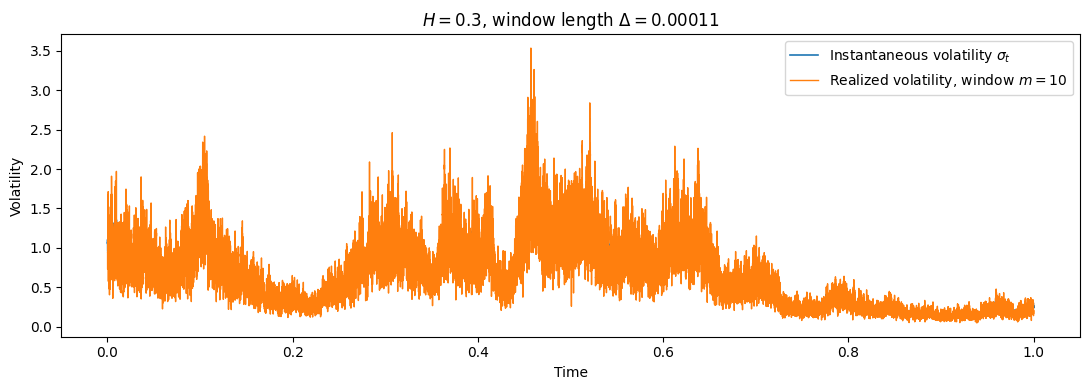

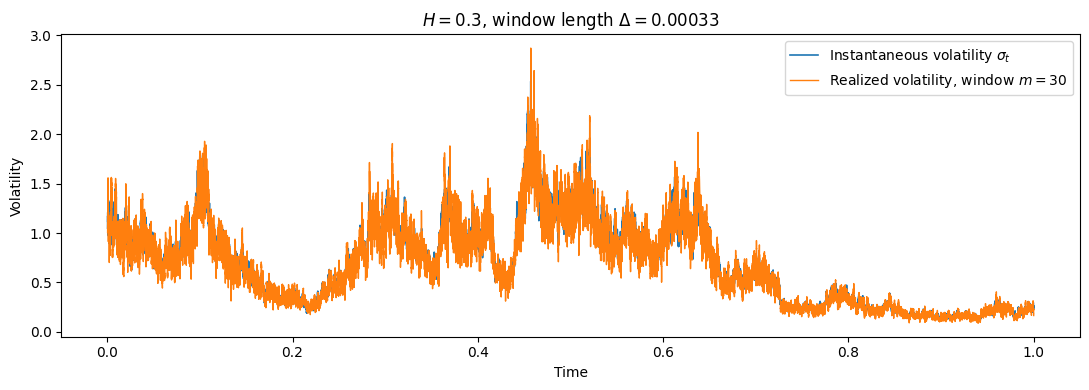

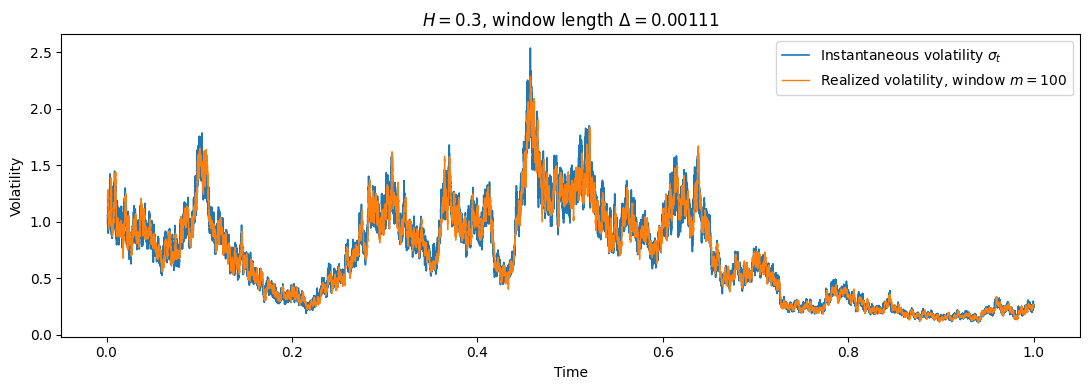

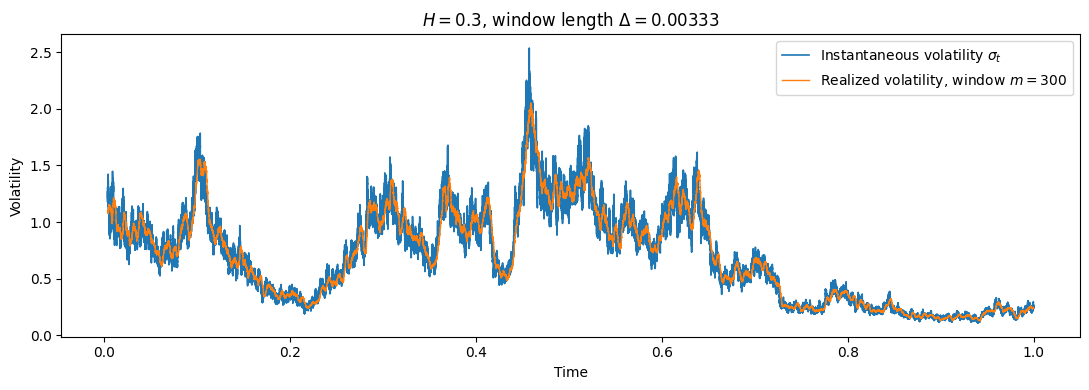

In [36]:
plot_sigma_and_rv_for_windows(
    H=0.3,
    N=300 * 300,
    T=1.0,
    windows=[10, 30, 100, 300],
    seed=123
)

##Comparing estimated Hurst for different window sizes

In [38]:
def compare_H_for_windows(
    H=0.3,
    N=300 * 300,
    T=1.0,
    windows=[30, 100, 300, 1000],
    K_est=300,
    seed=123
):
    """
    For one true H, estimate H from instantaneous volatility and
    realized volatility for several window sizes.
    """

    sim = simulate_fractional_ou_sv(
        H=H,
        N=N,
        T=T,
        gamma=1.0,
        theta=1.0,
        sigma0=1.0,
        S0=1.0,
        seed=seed
    )

    if isinstance(sim, dict):
        time = sim["time"]
        logS = sim["logS"]
        sigma = sim["sigma"]
    else:
        time, S, logS, sigma, dt = sim

    rows = []

    for m in windows:
        rv_time, rv, rv_indices = compute_realized_volatility_for_plot(
            logS=logS,
            time=time,
            window_size=m,
            step=1
        )

        sigma_aligned = sigma[rv_indices]

        H_sigma_hat = estimate_H(sigma_aligned, K=K_est, T=1.0)
        H_rv_hat = estimate_H(rv, K=K_est, T=1.0)

        Delta = m * (time[1] - time[0])

        rows.append({
            "window": m,
            "Delta": Delta,
            "H_sigma_hat": H_sigma_hat,
            "H_rv_hat": H_rv_hat
        })

    print("Window comparison:")
    for row in rows:
        print(
            f'window={row["window"]}, '
            f'Delta={row["Delta"]:.6f}, '
            f'H_hat(sigma)={row["H_sigma_hat"]:.4f}, '
            f'H_hat(RV)={row["H_rv_hat"]:.4f}'
        )

    return rows

rows = compare_H_for_windows(
    H=0.3,
    N=300 * 300,
    T=1.0,
    windows=[10, 30, 100, 300],
    K_est=300,
    seed=123
)

Window comparison:
window=10, Delta=0.000111, H_hat(sigma)=0.2906, H_hat(RV)=0.1852
window=30, Delta=0.000333, H_hat(sigma)=0.2805, H_hat(RV)=0.3298
window=100, Delta=0.001111, H_hat(sigma)=0.2838, H_hat(RV)=0.4989
window=300, Delta=0.003333, H_hat(sigma)=0.3017, H_hat(RV)=0.6576


#Just to convert into latex tables for ease

In [44]:
def window_comparison_to_beamer_latex(rows, H=0.3, N=300*300, K_est=300, digits=5):
    body = ""

    for row in rows:
        body += (
            f'{int(row["window"])} & '
            f'{row["Delta"]:.{digits}f} & '
            f'{row["H_sigma_hat"]:.{digits}f} & '
            f'{row["H_rv_hat"]:.{digits}f} \\\\\n'
        )

    latex = rf"""
\begin{{block}}{{Setup}}
We fix the true volatility roughness at $H={H}$ and use $N={N}$, $K={K_est}$.
For each window size $m$, realized volatility is computed from $m$ consecutive log returns.
\end{{block}}

\begin{{center}}
\begin{{tabular}}{{cccc}}
\hline
$m$ & $\Delta$ & $\widehat{{H}}(\sigma)$ & $\widehat{{H}}(RV)$ \\
\hline
{body}\hline
\end{{tabular}}
\end{{center}}

\begin{{alertblock}}{{Observation}}
The estimate from instantaneous volatility remains close to $H=0.3$, while the estimate from realized volatility changes strongly with the window size.
\end{{alertblock}}
"""
    return latex

In [45]:
print(window_comparison_to_beamer_latex(rows))


\begin{block}{Setup}
We fix the true volatility roughness at $H=0.3$ and use $N=90000$, $K=300$.
For each window size $m$, realized volatility is computed from $m$ consecutive log returns.
\end{block}

\begin{center}
\begin{tabular}{cccc}
\hline
$m$ & $\Delta$ & $\widehat{H}(\sigma)$ & $\widehat{H}(RV)$ \\
\hline
10 & 0.00011 & 0.29056 & 0.18523 \\
30 & 0.00033 & 0.28049 & 0.32981 \\
100 & 0.00111 & 0.28381 & 0.49889 \\
300 & 0.00333 & 0.30167 & 0.65755 \\
\hline
\end{tabular}
\end{center}

\begin{alertblock}{Observation}
The estimate from instantaneous volatility remains close to $H=0.3$, while the estimate from realized volatility changes strongly with the window size.
\end{alertblock}



#Experiment on market data
#Download 1-minute data, compute realized volatility for different window sizes, estimate H for each RV path, and return a table.

In [54]:
def download_1m_data_chunked(
    ticker="AAPL",
    start=None,
    end=None,
    max_days_back=29,
    chunk_days=7,
    regular_hours=True,
    timezone="America/New_York"
):
    if end is None:
        end_ts = pd.Timestamp.now(tz=timezone)
    else:
        end_ts = pd.Timestamp(end)
        if end_ts.tzinfo is None:
            end_ts = end_ts.tz_localize(timezone)

    if start is None:
        start_ts = end_ts - pd.Timedelta(days=max_days_back)
    else:
        start_ts = pd.Timestamp(start)
        if start_ts.tzinfo is None:
            start_ts = start_ts.tz_localize(timezone)

    # Warning if asking for too old 1-minute data
    oldest_allowed = pd.Timestamp.now(tz=timezone) - pd.Timedelta(days=60)

    if start_ts < oldest_allowed:
        print("Warning:")
        print("You are asking for 1-minute data older than about 60 days.")
        print("Yahoo/yfinance may return empty data for the older part.")
        print("Requested start:", start_ts)
        print("Approx oldest allowed:", oldest_allowed)

    all_chunks = []
    current_start = start_ts

    while current_start < end_ts:
        current_end = min(current_start + pd.Timedelta(days=chunk_days), end_ts)

        print(f"Downloading {ticker}: {current_start.date()} to {current_end.date()}")

        data = yf.download(
            ticker,
            start=current_start.strftime("%Y-%m-%d"),
            end=current_end.strftime("%Y-%m-%d"),
            interval="1m",
            auto_adjust=True,
            progress=False
        )

        if not data.empty:
            # Handle MultiIndex columns
            if isinstance(data.columns, pd.MultiIndex):
                close = data["Close"].iloc[:, 0]
            else:
                close = data["Close"]

            close = close.dropna()

            if len(close) > 0:
                all_chunks.append(close)

        current_start = current_end

    if len(all_chunks) == 0:
        raise ValueError(
            f"No 1-minute data downloaded for {ticker}. "
            "Try a more recent start date or a shorter period."
        )

    close = pd.concat(all_chunks)
    close = close[~close.index.duplicated(keep="first")]
    close = close.sort_index()
    close = close.dropna()

    # Convert timezone if needed
    if close.index.tz is None:
        close.index = close.index.tz_localize("UTC").tz_convert(timezone)
    else:
        close.index = close.index.tz_convert(timezone)

    if regular_hours:
        close = close.between_time("09:30", "16:00")

    close.name = ticker

    return close


def compute_realized_volatility_from_prices(
    prices,
    window_minutes=30,
    overlap=True,
    scale="raw"
):

    prices = prices.dropna()
    log_prices = np.log(prices)

    m = int(window_minutes)

    if m < 2:
        raise ValueError("window_minutes must be at least 2.")

    step = 1 if overlap else m

    rv_values = []
    rv_times = []

    for date, logp_day in log_prices.groupby(log_prices.index.date):

        returns = logp_day.diff().dropna()

        if len(returns) < m:
            continue

        for end in range(m, len(returns) + 1, step):
            window_returns = returns.iloc[end - m:end].values

            rv = np.sqrt(np.sum(window_returns ** 2))

            if scale == "per_minute":
                rv = rv / np.sqrt(m)
            elif scale != "raw":
                raise ValueError("scale must be 'raw' or 'per_minute'.")

            rv_values.append(rv)
            rv_times.append(returns.index[end - 1])

    rv = pd.Series(rv_values, index=pd.DatetimeIndex(rv_times))
    rv.name = f"RV_{window_minutes}min"

    return rv



def estimate_H_for_market_RV_windows(
    ticker="AAPL",
    start=None,
    end=None,
    windows_minutes=[2, 5, 10, 15, 30, 60],
    overlap=True,
    scale="raw",
    K_est=None,
    regular_hours=True,
    make_plots=False
):

    prices = download_1m_data_chunked(
        ticker=ticker,
        start=start,
        end=end,
        regular_hours=regular_hours
    )

    results = []
    rv_dict = {}

    for window in windows_minutes:

        rv = compute_realized_volatility_from_prices(
            prices=prices,
            window_minutes=window,
            overlap=overlap,
            scale=scale
        )

        rv_dict[window] = rv

        if len(rv) < 20:
            H_hat = np.nan
        else:
            H_hat = estimate_H(rv.values, K=K_est, T=1.0)

        results.append({
            "Ticker": ticker,
            "Window minutes": window,
            "Overlap": overlap,
            "Length RV": len(rv),
            "H_hat_RV": H_hat,
            "Mean RV": rv.mean(),
            "Std RV": rv.std()
        })

    results_df = pd.DataFrame(results)

    return results_df, prices, rv_dict

def market_RV_H_table_to_latex(results_df, digits=4):
    """
    Convert market realized-volatility H estimates to LaTeX.
    """

    rows = ""

    for _, row in results_df.iterrows():
        rows += (
            f'{int(row["Window minutes"])} & '
            f'{int(row["Length RV"])} & '
            f'{row["H_hat_RV"]:.{digits}f} \\\\\n'
        )

    latex = rf"""
\begin{{table}}[H]
\centering
\begin{{tabular}}{{cccc}}
\hline
RV window (minutes) & Length of RV path & $\widehat{{H}}(RV)$ \\
\hline
{rows}\hline
\end{{tabular}}
\caption{{Estimated roughness index of realized volatility for 1-minute market data. Realized volatility is computed using overlapping windows of log returns.}}
\end{{table}}
"""
    return latex


results_df, prices, rv_dict = estimate_H_for_market_RV_windows(
    ticker="AAPL",
    start=None,
    end=None,
    windows_minutes=[2, 5, 10, 15, 30, 60],
    overlap=True,
    scale="raw",
    K_est=None,
    regular_hours=True,
    make_plots=False
)

print(results_df)

print("\nLaTeX table:")
print(market_RV_H_table_to_latex(results_df, digits=4))

  Ticker  Window minutes  Overlap  Length RV  H_hat_RV   Mean RV    Std RV
0   AAPL               2     True       7372  0.113168  0.000863  0.000747
1   AAPL               5     True       7315  0.216760  0.001462  0.000988
2   AAPL              10     True       7220  0.326668  0.002094  0.001203
3   AAPL              15     True       7125  0.425849  0.002560  0.001332
4   AAPL              30     True       6840  0.502451  0.003579  0.001597
5   AAPL              60     True       6270  0.631332  0.004977  0.001921

LaTeX table:

\begin{table}[H]
\centering
\begin{tabular}{cccc}
\hline
RV window (minutes) & Length of RV path & $\widehat{H}(RV)$ \\
\hline
2 & 7372 & 0.1132 \\
5 & 7315 & 0.2168 \\
10 & 7220 & 0.3267 \\
15 & 7125 & 0.4258 \\
30 & 6840 & 0.5025 \\
60 & 6270 & 0.6313 \\
\hline
\end{tabular}
\caption{Estimated roughness index of realized volatility for 1-minute market data. Realized volatility is computed using overlapping windows of log returns.}
\end{table}



In [55]:
print("Downloaded price data summary")
print("-----------------------------")
print("Ticker:", prices.name)
print("Length of downloaded 1-minute prices:", len(prices))
print("Start:", prices.index.min())
print("End:", prices.index.max())
print("Trading days:", prices.index.normalize().nunique())

print("\nRealized-volatility path lengths")
print("--------------------------------")
for window, rv in rv_dict.items():
    print(f"RV window {window:>2} minutes: length = {len(rv)}")

Downloaded price data summary
-----------------------------
Ticker: AAPL
Length of downloaded 1-minute prices: 7410
Start: 2026-06-10 09:30:00-04:00
End: 2026-07-08 15:59:00-04:00
Trading days: 19

Realized-volatility path lengths
--------------------------------
RV window  2 minutes: length = 7372
RV window  5 minutes: length = 7315
RV window 10 minutes: length = 7220
RV window 15 minutes: length = 7125
RV window 30 minutes: length = 6840
RV window 60 minutes: length = 6270
